# Avaliação do Modelo — Credit Scoring Home Credit

Avalia o modelo campeão (LightGBM) salvo em `artifacts/model.joblib`: performance,
calibração de threshold por custo, importância e **explicabilidade (SHAP)**.

> Rode `python Model/train.py` antes deste notebook.

In [1]:
import joblib, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, confusion_matrix

ROOT = Path.cwd().parents[0] if Path.cwd().name == 'Model' else Path.cwd()
bundle = joblib.load(ROOT / 'artifacts' / 'model.joblib')
model = bundle['model']
print(json.dumps(bundle['metrics'], indent=2))

{
  "baseline": {
    "auc": 0.7711905265472693,
    "ks": 0.40554073783383826
  },
  "champion": {
    "auc": 0.7850385540411519,
    "ks": 0.4375862278654605,
    "auc_train": 0.8720520873416389,
    "auc_valid": 0.7807847639135729,
    "best_iteration": 654
  },
  "business": {
    "threshold": 0.5,
    "approval_rate": 0.7170823713049982,
    "cost_false_negative": 1.0,
    "cost_false_positive": 0.1
  }
}


## 1. Recriar o conjunto de teste

In [2]:
from sklearn.model_selection import train_test_split
df = pd.read_csv(ROOT / 'Dados' / 'abt.csv')
y = df['TARGET'].astype(int)
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
for c in bundle['categorical_features']:
    X[c] = pd.Categorical(X[c], categories=bundle['cat_categories'][c])
X = X[bundle['feature_names']]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
score = model.predict_proba(X_test)[:, 1]
print('AUC teste:', round(roc_auc_score(y_test, score), 4))

AUC teste: 0.785


## 2. Curvas ROC e Precision-Recall

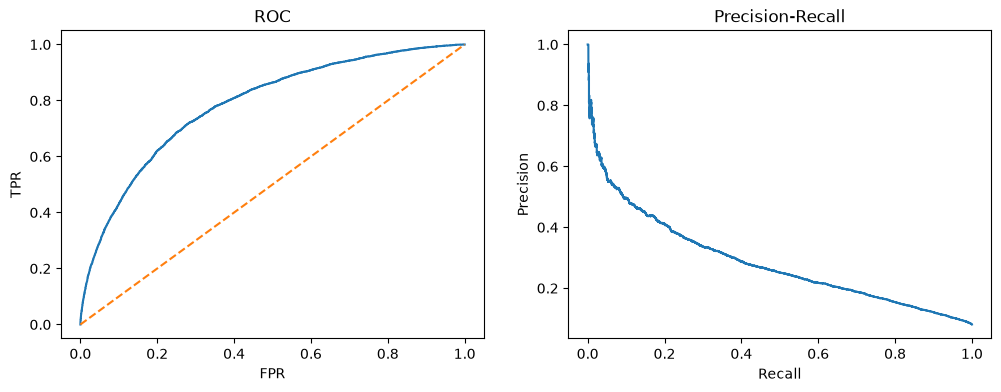

KS = 0.4376


In [3]:
fpr, tpr, _ = roc_curve(y_test, score)
prec, rec, _ = precision_recall_curve(y_test, score)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr); ax[0].plot([0,1],[0,1],'--'); ax[0].set_title('ROC'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[1].plot(rec, prec); ax[1].set_title('Precision-Recall'); ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
plt.show()
print('KS =', round(np.max(tpr - fpr), 4))

## 3. Threshold de negócio (matriz de custo) e matriz de confusão

Threshold de negócio: 0.5
Matriz de confusão [ [TN FP] [FN TP] ]:
 [[42749 13789]
 [ 1609  3356]]
Taxa de aprovação: 72.1%


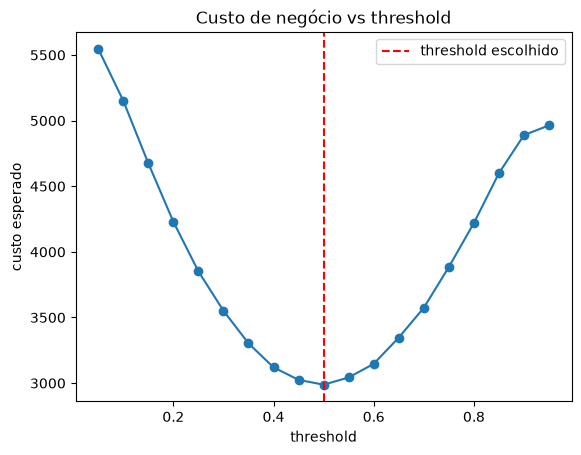

In [4]:
thr = bundle['threshold']
pred = (score >= thr).astype(int)
cm = confusion_matrix(y_test, pred)
print(f'Threshold de negócio: {thr}')
print('Matriz de confusão [ [TN FP] [FN TP] ]:\n', cm)
print(f'Taxa de aprovação: {(score < thr).mean():.1%}')
# Varredura de custo
b = bundle['metrics']['business']
ts = np.linspace(0.05, 0.95, 19)
costs = [b['cost_false_negative']*((score<t)&(y_test==1)).sum() + b['cost_false_positive']*((score>=t)&(y_test==0)).sum() for t in ts]
plt.plot(ts, costs, marker='o'); plt.axvline(thr, color='r', ls='--', label='threshold escolhido')
plt.xlabel('threshold'); plt.ylabel('custo esperado'); plt.legend(); plt.title('Custo de negócio vs threshold'); plt.show()

## 4. Importância de variáveis (LightGBM)

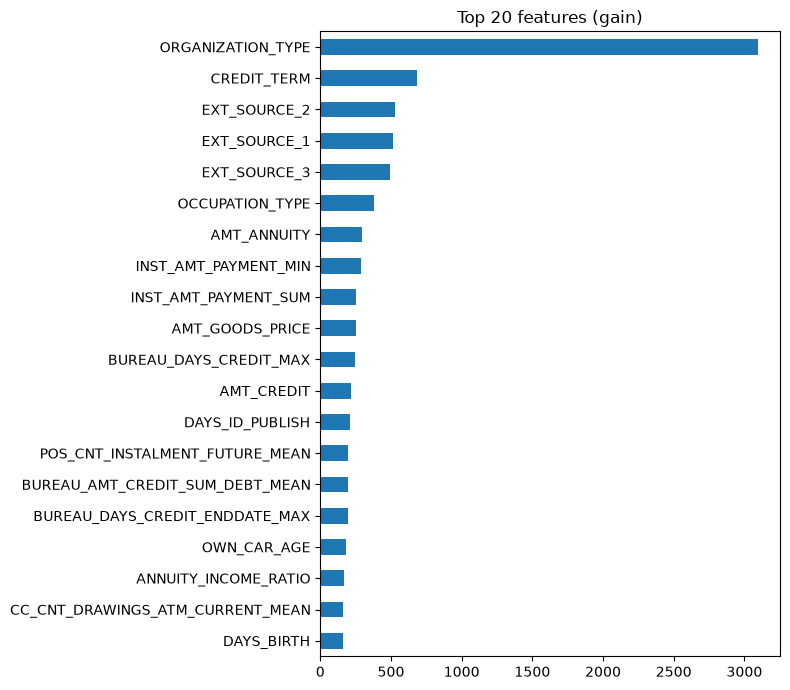

In [5]:
imp = pd.Series(model.feature_importances_, index=bundle['feature_names']).sort_values(ascending=False).head(20)
imp[::-1].plot(kind='barh', figsize=(8, 7), title='Top 20 features (gain)'); plt.tight_layout(); plt.show()

## 5. Explicabilidade — SHAP

SHAP traduz o modelo (caixa-preta) em contribuições por variável — essencial para
**governança de crédito** e defesa na banca.

/home/victor/workspace/fia_tcc/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


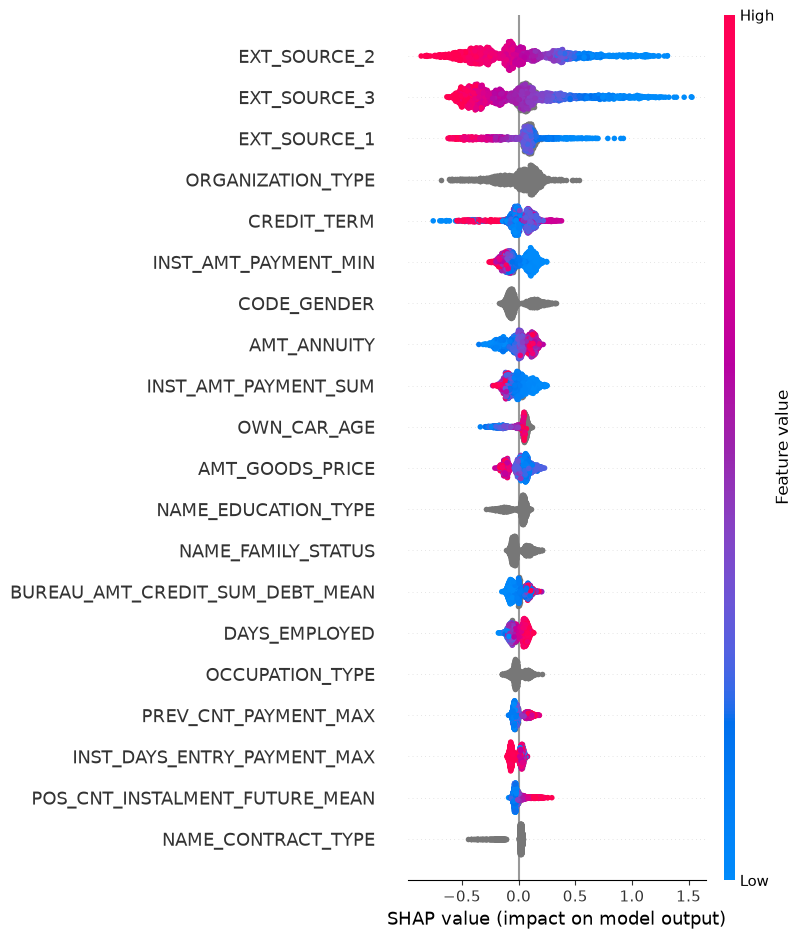

In [6]:
import shap
sample = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=20)

## Diagnóstico crítico (Results / Governança)

- **Overfitting**: comparar AUC treino vs. validação/teste (early stopping atua como controle).
- **Viés**: avaliar performance por segmento sensível (gênero, idade, thin-file).
- **Cenários de falha**: clientes sem histórico de bureau têm menos sinal — risco de score instável.
- **Confiança**: AUC ~0.78 + KS ~0.44 dão poder de ordenação suficiente para a régua de decisão;
  a matriz de custo conecta a métrica técnica ao impacto financeiro.
- **Métricas de monitoramento sugeridas**: PSI das features, drift do score, AUC em janela móvel,
  taxa de aprovação e inadimplência observada (back-testing).